In [2]:
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 
df = pd.read_csv("churn.csv")
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
df = df.drop_duplicates()
df.isnull().sum()
df = df.dropna()
df["Age"].fillna(df["Age"].median(), inplace=True)


C:\Users\Pratham\AppData\Local\Temp\ipykernel_34996\3276065835.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Age"].fillna(df["Age"].median(), inplace=True)


In [4]:
df["Gender"] = df["Gender"].astype("category")
df["Geography"] = df["Geography"].astype("category")


In [5]:
# Check invalid values
df[df["Age"] <= 0]
df[df["Tenure"] < 0]
df[df["Balance"] < 0]
df = df[(df["Age"] > 0) & (df["Tenure"] >= 0)]


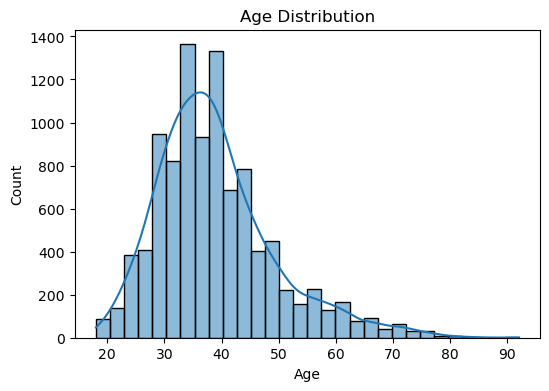

In [6]:
plt.figure(figsize=(6,4))
sns.histplot(df["Age"], bins=30, kde=True)
plt.title("Age Distribution")
plt.show()


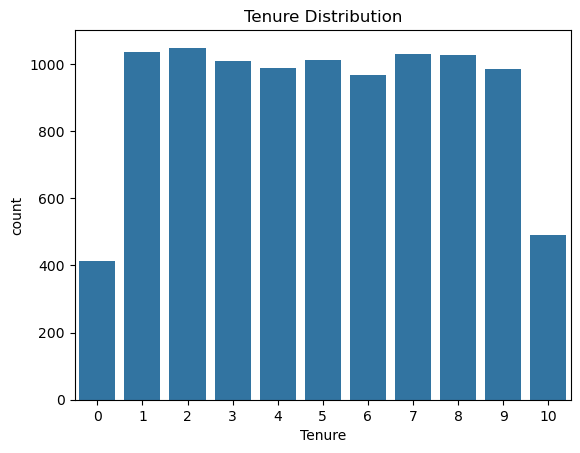

In [7]:
sns.countplot(x="Tenure", data=df)
plt.title("Tenure Distribution")
plt.show()


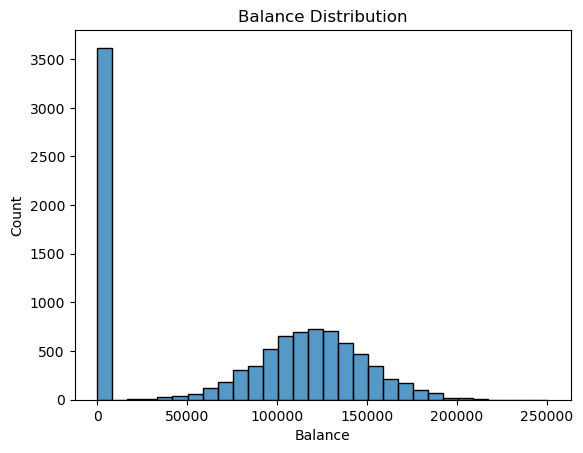

In [8]:
sns.histplot(df["Balance"], bins=30)
plt.title("Balance Distribution")
plt.show()


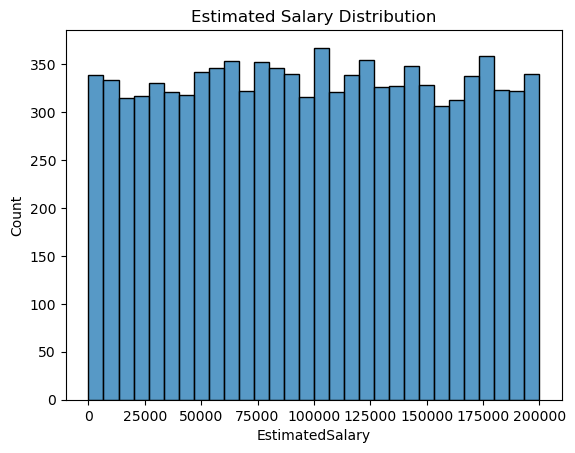

In [9]:
sns.histplot(df["EstimatedSalary"], bins=30)
plt.title("Estimated Salary Distribution")
plt.show()


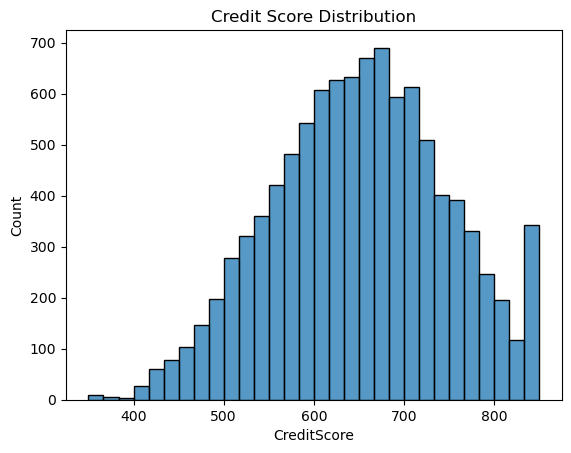

In [10]:
sns.histplot(df["CreditScore"], bins=30)
plt.title("Credit Score Distribution")
plt.show()


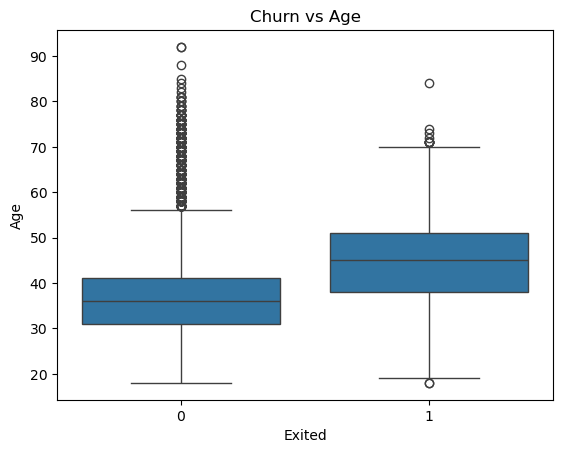

In [11]:
sns.boxplot(x="Exited", y="Age", data=df)
plt.title("Churn vs Age")
plt.show()


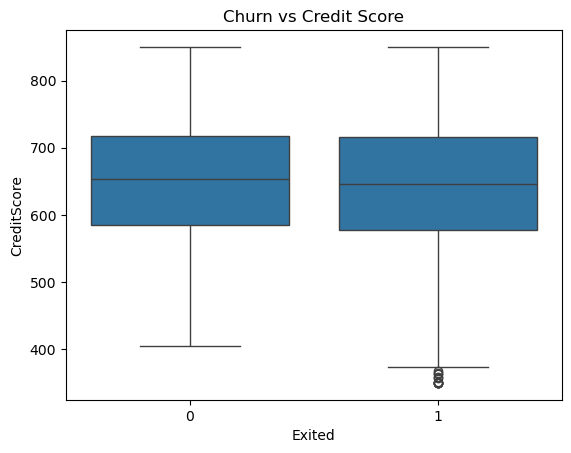

In [12]:
sns.boxplot(x="Exited", y="CreditScore", data=df)
plt.title("Churn vs Credit Score")
plt.show()


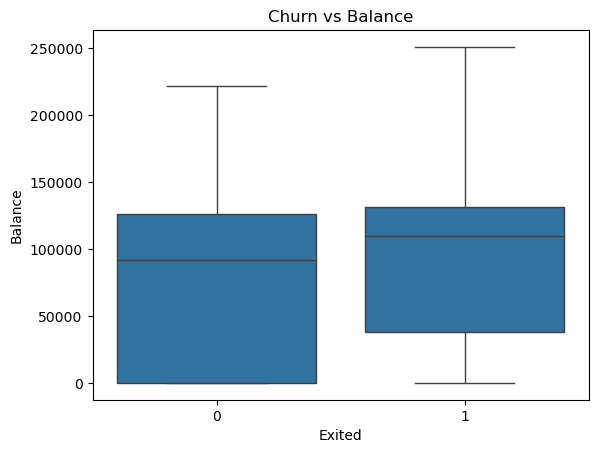

In [13]:
sns.boxplot(x="Exited", y="Balance", data=df)
plt.title("Churn vs Balance")
plt.show()


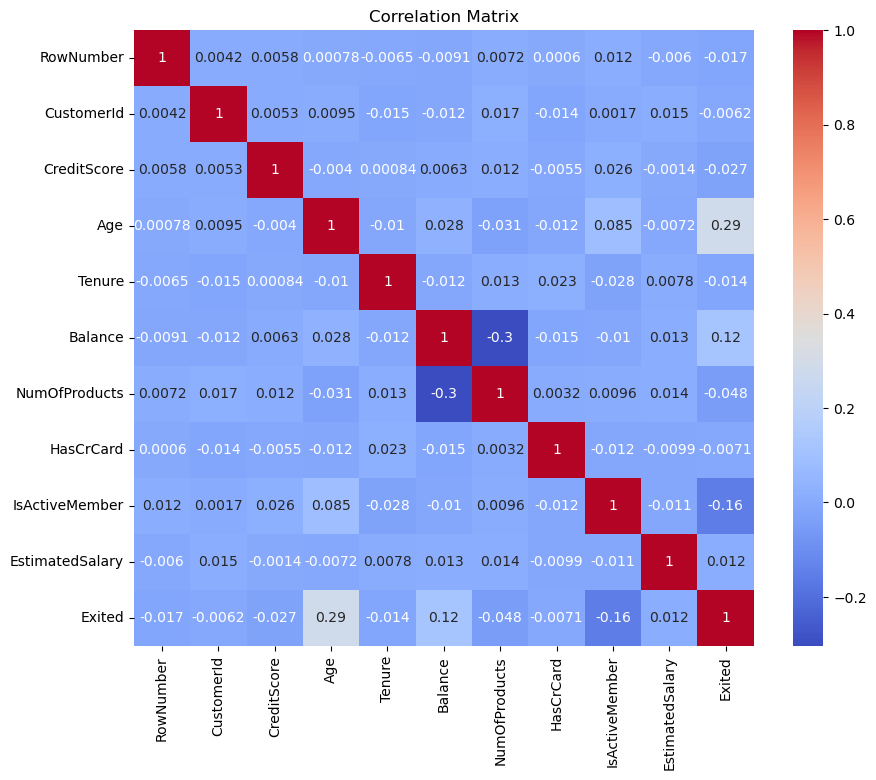

In [14]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()
